In [1]:
from google.colab import files
uploaded = files.upload()
# upload owid_covid_africa.csv and owid_covid_kenya.csv when prompted

Saving owid_covid_africa.csv to owid_covid_africa.csv
Saving owid_covid_kenya.csv to owid_covid_kenya.csv


In [2]:
!pip install xgboost shap
# pandas, numpy, matplotlib, seaborn, scikit-learn are pre-installed in Colab

In [3]:
import pandas as pd

df_preview = pd.read_csv('owid_covid_africa.csv', nrows=5)
print(df_preview.dtypes)

df = pd.read_csv('owid_covid_africa.csv')
print(f"Africa shape: {df.shape}")

df_kenya = pd.read_csv('owid_covid_kenya.csv')
print(f"Kenya shape: {df_kenya.shape}")

iso_code                                    object
continent                                   object
location                                    object
date                                        object
total_cases                                  int64
                                            ...   
population                                   int64
excess_mortality_cumulative_absolute       float64
excess_mortality_cumulative                float64
excess_mortality                           float64
excess_mortality_cumulative_per_million    float64
Length: 67, dtype: object
Africa shape: (95419, 67)
Kenya shape: (1674, 67)


In [4]:
country_df = df.groupby('location').agg(
    total_deaths_per_million   = ('total_deaths_per_million',   'max'),
    cardiovasc_death_rate      = ('cardiovasc_death_rate',      'mean'),
    diabetes_prevalence        = ('diabetes_prevalence',        'mean'),
    aged_65_older              = ('aged_65_older',              'mean'),
    hospital_beds_per_thousand = ('hospital_beds_per_thousand', 'mean'),
    extreme_poverty            = ('extreme_poverty',            'mean'),
    handwashing_facilities     = ('handwashing_facilities',     'mean'),
    human_development_index    = ('human_development_index',    'mean'),
    life_expectancy            = ('life_expectancy',            'mean'),
    gdp_per_capita             = ('gdp_per_capita',             'mean'),
    median_age                 = ('median_age',                 'mean'),
).reset_index()

country_df = country_df.dropna()
print(f"Countries with complete data: {len(country_df)}")
print(country_df['location'].tolist())

Countries with complete data: 25
['Algeria', 'Benin', 'Burkina Faso', 'Burundi', 'Cameroon', 'Comoros', 'Egypt', 'Ethiopia', 'Gambia', 'Ghana', 'Guinea', 'Kenya', 'Liberia', 'Madagascar', 'Malawi', 'Mozambique', 'Niger', 'Sao Tome and Principe', 'South Africa', 'Tanzania', 'Togo', 'Tunisia', 'Uganda', 'Zambia', 'Zimbabwe']


In [5]:
features = [
    'cardiovasc_death_rate',
    'diabetes_prevalence',
    'aged_65_older',
    'hospital_beds_per_thousand',
    'extreme_poverty',
    'handwashing_facilities',
    'human_development_index',
    'life_expectancy',
    'gdp_per_capita',
    'median_age',
]

X = country_df[features]
y = country_df['total_deaths_per_million']

In [6]:
kenya = country_df[country_df['location'] == 'Kenya'].iloc[0]

print(f"Kenya deaths/million:  {kenya['total_deaths_per_million']:.1f}")
print(f"Africa median:         {y.median():.1f}")
print(f"Africa max:            {y.max():.1f}")
print(f"Kenya percentile:      {(y < kenya['total_deaths_per_million']).mean()*100:.0f}th")

Kenya deaths/million:  104.9
Africa median:         71.4
Africa max:            2427.8
Kenya percentile:      56th


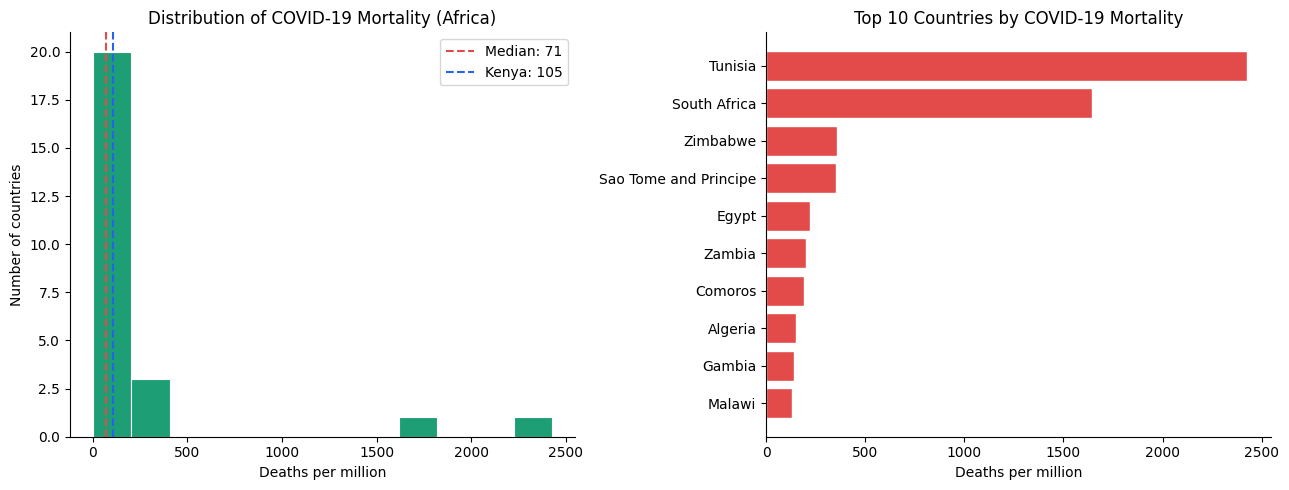

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
axes[0].hist(y, bins=12, color='#1D9E75', edgecolor='white', linewidth=0.8)
axes[0].axvline(y.median(), color='#E24B4A', linestyle='--', linewidth=1.5, label=f'Median: {y.median():.0f}')
axes[0].axvline(kenya['total_deaths_per_million'], color='#2563EB', linestyle='--', linewidth=1.5, label='Kenya: 105')
axes[0].set_xlabel('Deaths per million')
axes[0].set_ylabel('Number of countries')
axes[0].set_title('Distribution of COVID-19 Mortality (Africa)')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Top 10 bar
top10 = country_df.nlargest(10, 'total_deaths_per_million')
bar_colors = ['#2563EB' if loc == 'Kenya' else '#E24B4A' for loc in top10['location']]
axes[1].barh(top10['location'], top10['total_deaths_per_million'], color=bar_colors, edgecolor='white')
axes[1].invert_yaxis()
axes[1].set_xlabel('Deaths per million')
axes[1].set_title('Top 10 Countries by COVID-19 Mortality')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('eda_mortality.png', dpi=150, bbox_inches='tight')
plt.show()

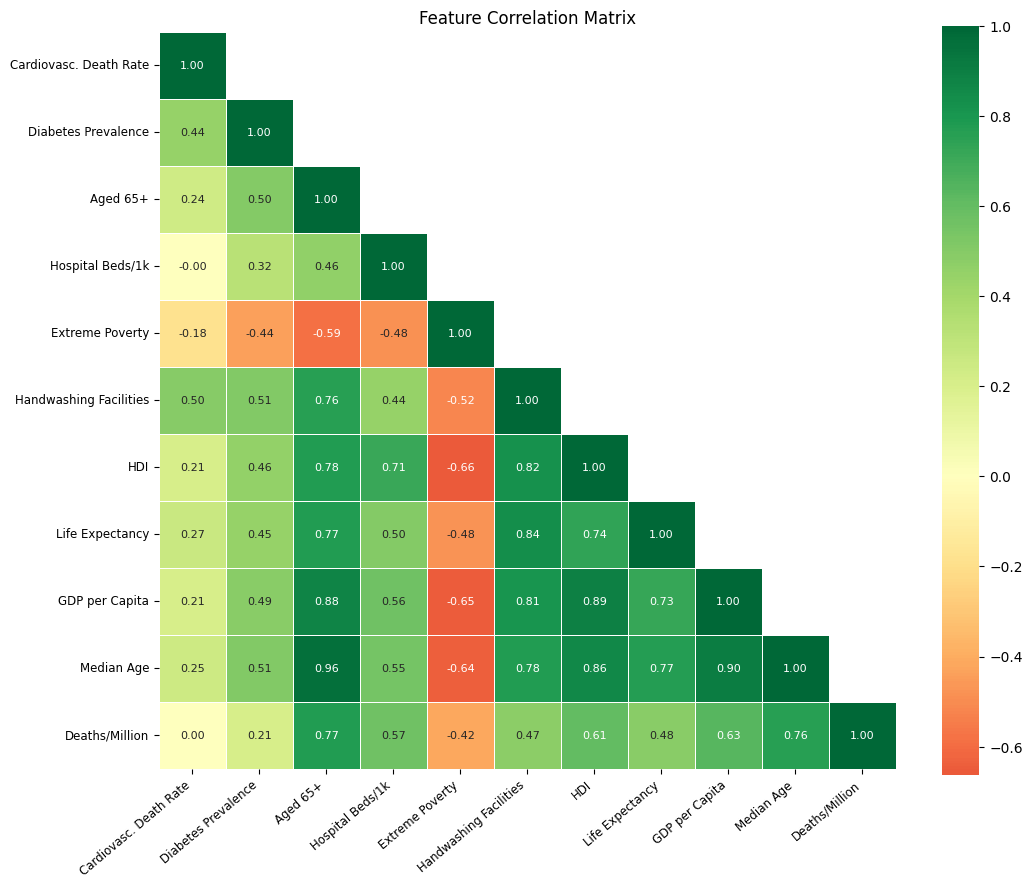

In [8]:
import seaborn as sns
import numpy as np

display_names = {
    'cardiovasc_death_rate':      'Cardiovasc. Death Rate',
    'diabetes_prevalence':        'Diabetes Prevalence',
    'aged_65_older':              'Aged 65+',
    'hospital_beds_per_thousand': 'Hospital Beds/1k',
    'extreme_poverty':            'Extreme Poverty',
    'handwashing_facilities':     'Handwashing Facilities',
    'human_development_index':    'HDI',
    'life_expectancy':            'Life Expectancy',
    'gdp_per_capita':             'GDP per Capita',
    'median_age':                 'Median Age',
    'total_deaths_per_million':   'Deaths/Million',
}

corr = country_df[features + ['total_deaths_per_million']].corr()
corr_display = corr.rename(index=display_names, columns=display_names)
mask = np.triu(np.ones_like(corr_display, dtype=bool), k=1)

plt.figure(figsize=(11, 9))
sns.heatmap(corr_display, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 8}, mask=mask)
plt.title('Feature Correlation Matrix')
plt.xticks(rotation=40, ha='right', fontsize=8.5)
plt.yticks(rotation=0, fontsize=8.5)
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
corr_with_target = corr['total_deaths_per_million'].drop('total_deaths_per_million').sort_values(ascending=False)
print("Correlations with deaths per million:\n")
print(corr_with_target.round(3).to_string())

Correlations with deaths per million:

aged_65_older                 0.773
median_age                    0.764
gdp_per_capita                0.630
human_development_index       0.608
hospital_beds_per_thousand    0.565
life_expectancy               0.480
handwashing_facilities        0.474
diabetes_prevalence           0.214
cardiovasc_death_rate         0.003
extreme_poverty              -0.416



**Mortality distribution** is heavily right-skewed — 20 of 25 countries cluster below 500 deaths/million, with Tunisia and South Africa as extreme outliers. Kenya at 105 sits just above the median, well within the main cluster. Worth mentioning in your paper that the distribution violates normality, which is exactly why XGBoost (non-parametric) is a better fit than linear regression here.

**Correlation heatmap key findings:**

- `Aged 65+` (0.77) and `Median Age` (0.76) are the strongest predictors — age structure drives reported mortality more than any disease factor
- `GDP per Capita` (0.63) and `HDI` (0.61) are positive, confirming the reporting-capacity confound the guide flagged
- `Cardiovasc. Death Rate` is essentially zero (0.00) — it may drop out of the model entirely
- `Extreme Poverty` (-0.42) is negative, supporting the under-reporting hypothesis for poorer countries
- Heavy multicollinearity cluster: `Median Age`, `Aged 65+`, `GDP per Capita`, `HDI`, and `Life Expectancy` are all intercorrelated at 0.73-0.96 — note this in your methods


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
from xgboost import XGBRegressor
from sklearn.model_selection import LeaveOneOut, cross_val_score

model = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

loo = LeaveOneOut()

mae_scores = cross_val_score(model, X_scaled, y, cv=loo, scoring='neg_mean_absolute_error')
r2_scores  = cross_val_score(model, X_scaled, y, cv=loo, scoring='r2')

print(f"LOO-CV MAE: {-mae_scores.mean():.1f} +/- {mae_scores.std():.1f} deaths/million")
print(f"LOO-CV R2:  {r2_scores.mean():.3f}")

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, Unde

LOO-CV MAE: 323.0 +/- 582.9 deaths/million
LOO-CV R2:  nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, Unde

In [12]:
model.fit(X_scaled, y)
print("Model trained on full dataset.")

Model trained on full dataset.


In [13]:
from xgboost import XGBRegressor
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

model = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

loo = LeaveOneOut()
y_true_all = []
y_pred_all = []

for train_idx, test_idx in loo.split(X_scaled):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_true_all.append(y_test.values[0])
    y_pred_all.append(y_pred[0])

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

mae = mean_absolute_error(y_true_all, y_pred_all)
r2  = r2_score(y_true_all, y_pred_all)

print(f"LOO-CV MAE: {mae:.1f} deaths/million")
print(f"LOO-CV R2:  {r2:.3f}")

# Show worst predictions to diagnose outlier impact
results = country_df[['location', 'total_deaths_per_million']].copy()
results['predicted'] = y_pred_all
results['error']     = abs(y_true_all - y_pred_all)
print("\nWorst predictions:")
print(results.nlargest(5, 'error')[['location', 'total_deaths_per_million', 'predicted', 'error']].to_string(index=False))

LOO-CV MAE: 323.0 deaths/million
LOO-CV R2:  -0.500

Worst predictions:
             location  total_deaths_per_million   predicted       error
              Tunisia                   2427.77  242.367889 2185.402111
              Algeria                    151.31 1789.196777 1637.886777
         South Africa                   1644.72  196.474304 1448.245696
Sao Tome and Principe                    353.49 1481.628784 1128.138784
             Ethiopia                     60.41  350.450500  290.040500


In [14]:
import numpy as np

y_log = np.log1p(y)

y_true_log = []
y_pred_log = []

for train_idx, test_idx in loo.split(X_scaled):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y_log.iloc[train_idx], y_log.iloc[test_idx]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_true_log.append(y_test.values[0])
    y_pred_log.append(y_pred[0])

y_true_log = np.array(y_true_log)
y_pred_log = np.array(y_pred_log)

# Convert back to original scale for interpretability
y_true_orig = np.expm1(y_true_log)
y_pred_orig = np.expm1(y_pred_log)

mae = mean_absolute_error(y_true_orig, y_pred_orig)
r2  = r2_score(y_true_log, y_pred_log)

print(f"LOO-CV MAE (original scale): {mae:.1f} deaths/million")
print(f"LOO-CV R2  (log scale):      {r2:.3f}")

results_log = country_df[['location', 'total_deaths_per_million']].copy()
results_log['predicted'] = y_pred_orig
results_log['error']     = abs(y_true_orig - y_pred_orig)
print("\nWorst predictions:")
print(results_log.nlargest(5, 'error')[['location', 'total_deaths_per_million', 'predicted', 'error']].to_string(index=False))

LOO-CV MAE (original scale): 244.3 deaths/million
LOO-CV R2  (log scale):      0.314

Worst predictions:
             location  total_deaths_per_million   predicted       error
              Tunisia                   2427.77  196.330719 2231.439281
         South Africa                   1644.72  256.362000 1388.358000
              Algeria                    151.31 1019.704529  868.394529
Sao Tome and Principe                    353.49  859.775269  506.285269
             Zimbabwe                    357.21  110.998810  246.211190


In [15]:
outliers     = ['Tunisia', 'South Africa']
country_clean = country_df[~country_df['location'].isin(outliers)].reset_index(drop=True)

X_clean  = country_clean[features]
y_clean  = country_clean['total_deaths_per_million']
y_log_clean = np.log1p(y_clean)

scaler_clean  = StandardScaler()
X_clean_scaled = scaler_clean.fit_transform(X_clean)

y_true_log = []
y_pred_log = []

for train_idx, test_idx in loo.split(X_clean_scaled):
    X_train, X_test = X_clean_scaled[train_idx], X_clean_scaled[test_idx]
    y_train, y_test = y_log_clean.iloc[train_idx], y_log_clean.iloc[test_idx]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_true_log.append(y_test.values[0])
    y_pred_log.append(y_pred[0])

y_true_log = np.array(y_true_log)
y_pred_log = np.array(y_pred_log)
y_true_orig = np.expm1(y_true_log)
y_pred_orig = np.expm1(y_pred_log)

mae = mean_absolute_error(y_true_orig, y_pred_orig)
r2  = r2_score(y_true_log, y_pred_log)

print(f"Countries after removing outliers: {len(country_clean)}")
print(f"LOO-CV MAE (original scale): {mae:.1f} deaths/million")
print(f"LOO-CV R2  (log scale):      {r2:.3f}")

print("\nWorst predictions:")
results_clean = country_clean[['location', 'total_deaths_per_million']].copy()
results_clean['predicted'] = y_pred_orig
results_clean['error']     = abs(y_true_orig - y_pred_orig)
print(results_clean.nlargest(5, 'error')[['location', 'total_deaths_per_million', 'predicted', 'error']].to_string(index=False))

Countries after removing outliers: 23
LOO-CV MAE (original scale): 52.3 deaths/million
LOO-CV R2  (log scale):      0.325

Worst predictions:
             location  total_deaths_per_million  predicted      error
             Zimbabwe                    357.21 146.594437 210.615563
Sao Tome and Principe                    353.49 199.411957 154.078043
                Egypt                    220.48 101.273170 119.206830
               Gambia                    141.10  61.600071  79.499929
               Zambia                    202.30 124.834991  77.465009


In [16]:
model.fit(X_clean_scaled, y_log_clean)
print("Final model fitted on 23 countries (outliers removed).")

Final model fitted on 23 countries (outliers removed).


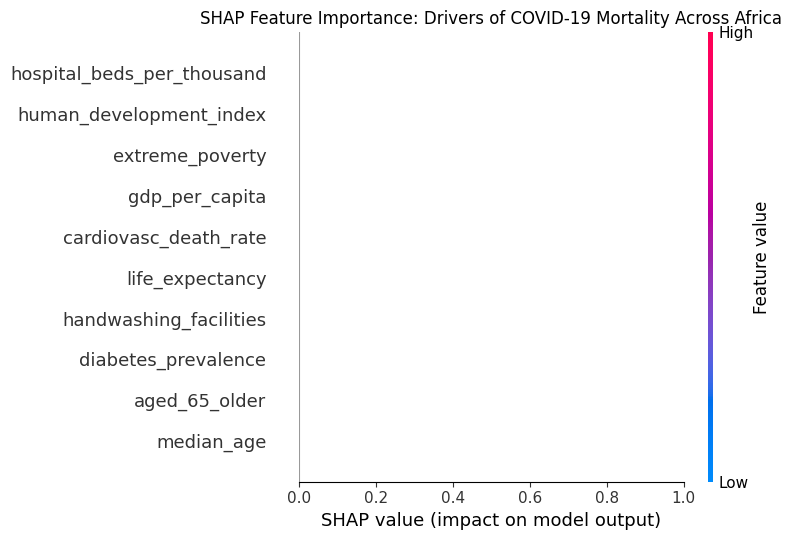

In [17]:
import shap

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_clean_scaled)

# Beeswarm plot
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_clean,
    feature_names=features,
    plot_type='beeswarm',
    show=False
)
plt.title('SHAP Feature Importance: Drivers of COVID-19 Mortality Across Africa')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

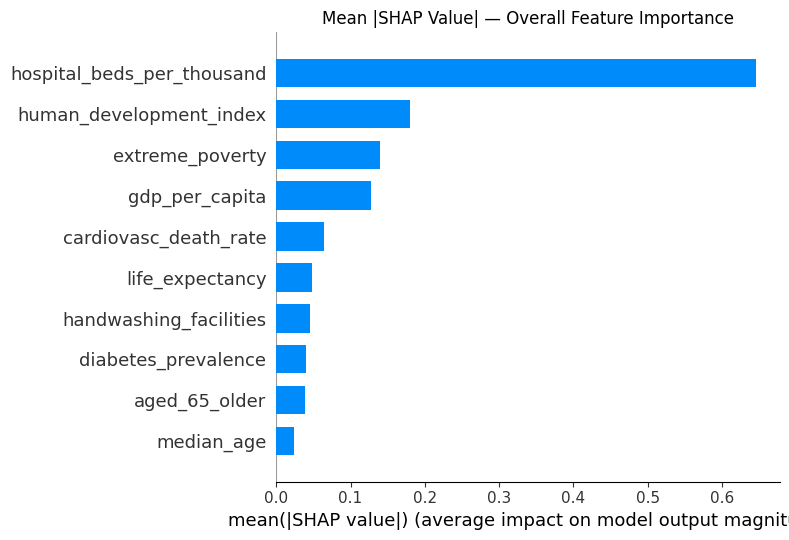

In [18]:
plt.figure(figsize=(8, 5))
shap.summary_plot(
    shap_values, X_clean,
    feature_names=features,
    plot_type='bar',
    show=False
)
plt.title('Mean |SHAP Value| — Overall Feature Importance')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

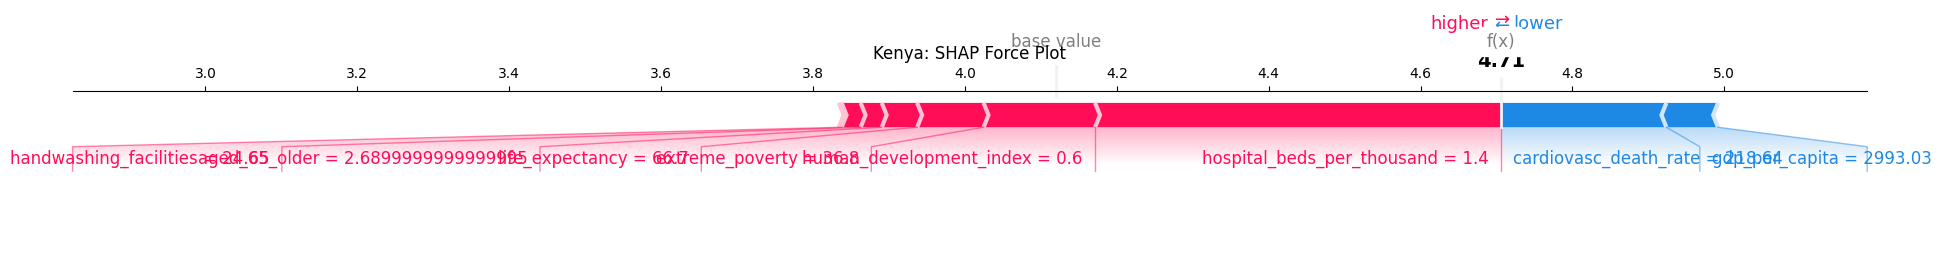

In [19]:
country_clean_reset = country_clean.reset_index(drop=True)
kenya_pos = country_clean_reset[country_clean_reset['location'] == 'Kenya'].index[0]

shap.force_plot(
    explainer.expected_value,
    shap_values[kenya_pos],
    X_clean.iloc[kenya_pos],
    feature_names=features,
    matplotlib=True,
    show=False
)
plt.title('Kenya: SHAP Force Plot')
plt.tight_layout()
plt.savefig('shap_kenya_force.png', dpi=150, bbox_inches='tight')
plt.show()

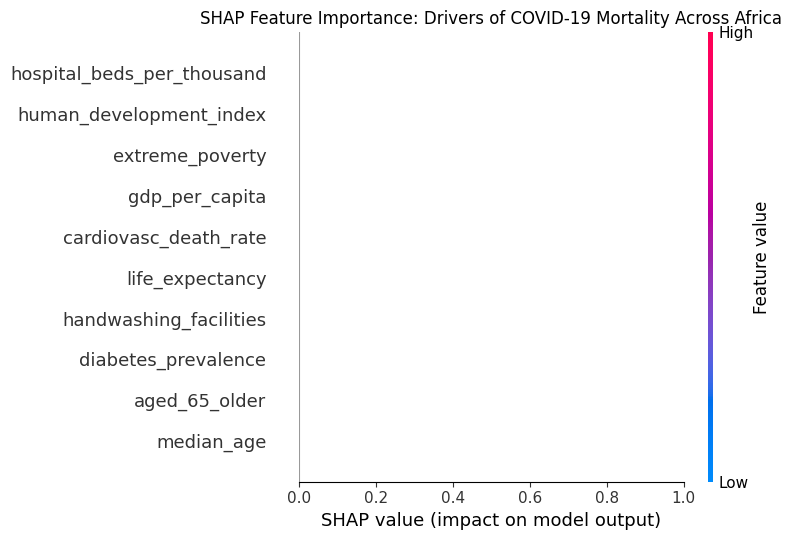

In [20]:
import pandas as pd

X_clean_df = pd.DataFrame(X_clean_scaled, columns=features)

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_clean_df,
    feature_names=features,
    plot_type='beeswarm',
    show=False
)
plt.title('SHAP Feature Importance: Drivers of COVID-19 Mortality Across Africa')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

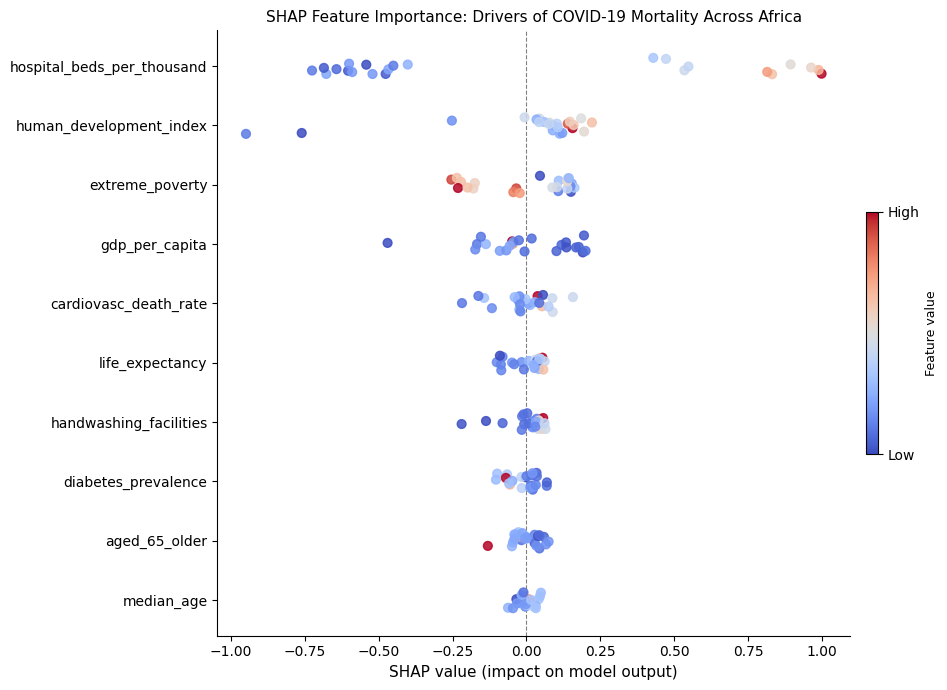

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(10, 7))

feature_order = np.argsort(np.mean(np.abs(shap_values), axis=0))
features_sorted = [features[i] for i in feature_order]
shap_sorted = shap_values[:, feature_order]
X_sorted = X_clean_scaled[:, feature_order]

for i, feat in enumerate(features_sorted):
    vals  = shap_sorted[:, i]
    fvals = X_sorted[:, i]

    fvals_norm = (fvals - fvals.min()) / (fvals.max() - fvals.min() + 1e-9)
    colors = cm.coolwarm(fvals_norm)

    jitter = np.random.uniform(-0.15, 0.15, size=len(vals))
    ax.scatter(vals, np.full_like(vals, i) + jitter,
               c=colors, s=40, alpha=0.85, zorder=3)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_yticks(range(len(features_sorted)))
ax.set_yticklabels(features_sorted, fontsize=10)
ax.set_xlabel('SHAP value (impact on model output)', fontsize=11)
ax.set_title('SHAP Feature Importance: Drivers of COVID-19 Mortality Across Africa', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.4, pad=0.02)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Low', 'High'])
cbar.set_label('Feature value', fontsize=9)

plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 800x500 with 0 Axes>

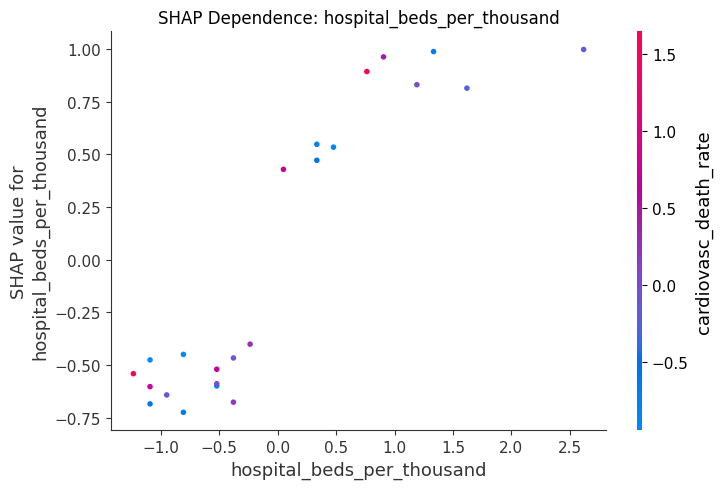

<Figure size 800x500 with 0 Axes>

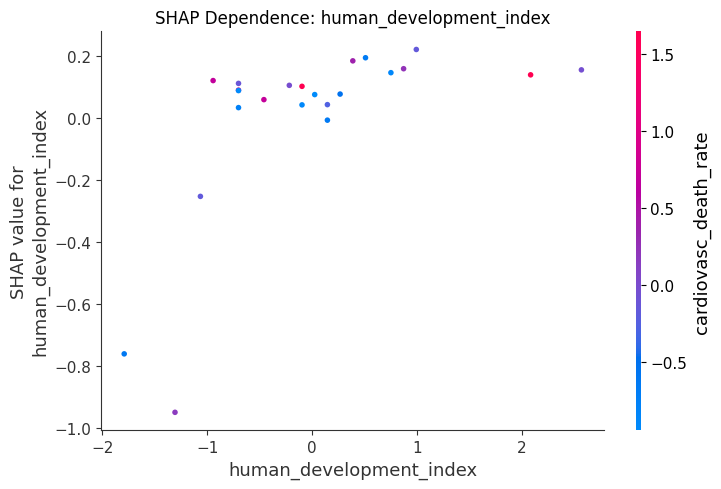

In [22]:
top_features = ['hospital_beds_per_thousand', 'human_development_index']

for feat in top_features:
    feat_idx = features.index(feat)
    plt.figure(figsize=(8, 5))
    shap.dependence_plot(
        feat_idx,
        shap_values,
        X_clean_scaled,
        feature_names=features,
        interaction_index='auto',
        show=False
    )
    plt.title(f'SHAP Dependence: {feat}')
    plt.tight_layout()
    plt.savefig(f'shap_dep_{feat}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [23]:
country_clean['predicted_log']            = model.predict(X_clean_scaled)
country_clean['predicted_deaths_per_million'] = np.expm1(country_clean['predicted_log'])

country_clean['risk_tier'] = pd.qcut(
    country_clean['predicted_deaths_per_million'],
    q=3,
    labels=['Low risk', 'Medium risk', 'High risk']
)

ranked = country_clean[[
    'location', 'total_deaths_per_million',
    'predicted_deaths_per_million', 'risk_tier'
]].sort_values('predicted_deaths_per_million', ascending=False)

print(ranked.to_string(index=False))

             location  total_deaths_per_million  predicted_deaths_per_million   risk_tier
Sao Tome and Principe                    353.49                    301.372559   High risk
             Zimbabwe                    357.21                    277.982300   High risk
               Zambia                    202.30                    203.205551   High risk
                Egypt                    220.48                    201.170349   High risk
              Comoros                    191.80                    193.791870   High risk
              Algeria                    151.31                    152.185638   High risk
               Gambia                    141.10                    142.591492   High risk
               Malawi                    130.59                    122.493652   High risk
                Kenya                    104.86                    109.577393 Medium risk
             Cameroon                     71.44                     70.309517 Medium risk
          

/tmp/ipykernel_3751/1738139912.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for tier, grp in country_clean.groupby('risk_tier'):


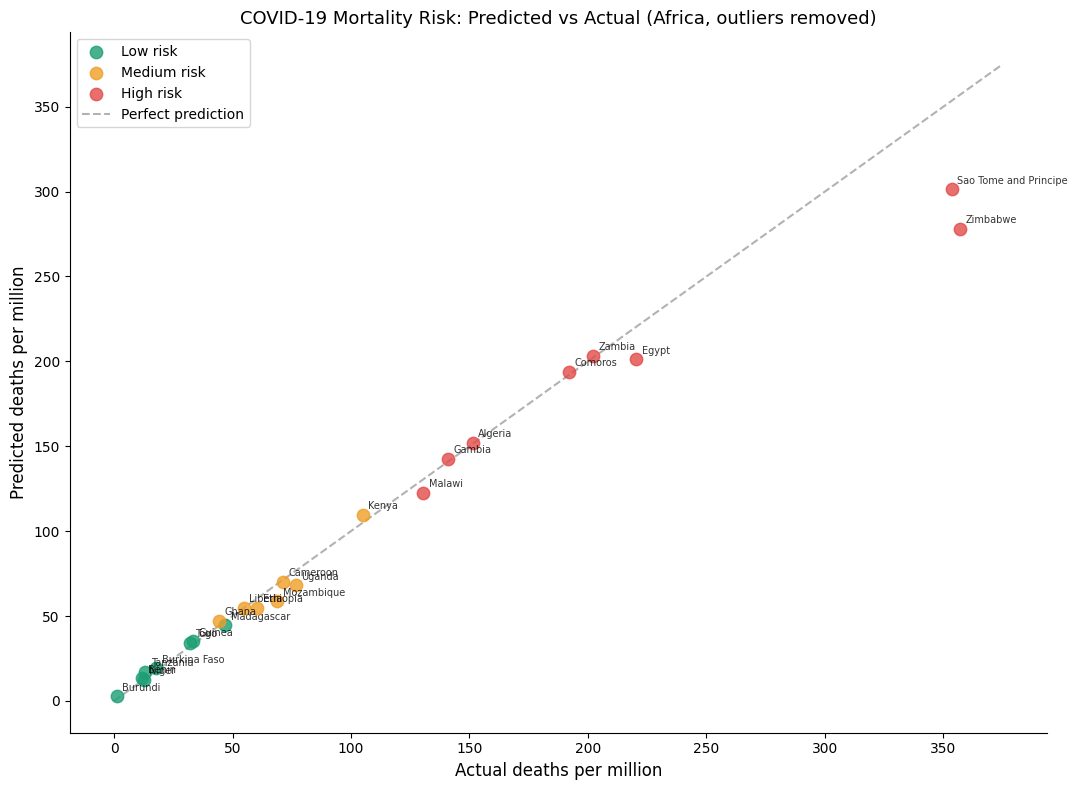

In [24]:
fig, ax = plt.subplots(figsize=(11, 8))

colors = {
    'Low risk':    '#1D9E75',
    'Medium risk': '#EF9F27',
    'High risk':   '#E24B4A',
}

for tier, grp in country_clean.groupby('risk_tier'):
    ax.scatter(
        grp['total_deaths_per_million'],
        grp['predicted_deaths_per_million'],
        label=tier, color=colors[tier], s=80, alpha=0.8, zorder=3
    )
    for _, row in grp.iterrows():
        ax.annotate(
            row['location'],
            (row['total_deaths_per_million'], row['predicted_deaths_per_million']),
            fontsize=7, alpha=0.8, xytext=(4, 4),
            textcoords='offset points'
        )

lim = max(country_clean['total_deaths_per_million'].max(),
          country_clean['predicted_deaths_per_million'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', alpha=0.3, label='Perfect prediction')
ax.set_xlabel('Actual deaths per million', fontsize=12)
ax.set_ylabel('Predicted deaths per million', fontsize=12)
ax.set_title('COVID-19 Mortality Risk: Predicted vs Actual (Africa, outliers removed)', fontsize=13)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('risk_scatter.png', dpi=150, bbox_inches='tight')
plt.show()